# Part 3 — Rain / wet-snow / dry-snow classifier from CML attenuation

Can the CML signal **alone** tell rain from wet snow from dry snow? Ground truth is the
hourly phase index; snow is split into wet/dry by a temperature proxy (`T ≥ −2 °C` = wet,
near-melting; `T < −2 °C` = dry). Because temperature *defines* the label, every model is
run **with and without temperature as a feature** — a good without-temp score is the
'CML-alone' claim.

Logic lives in `methods/cml_classifier.py`; cells are thin. Sections: **3.1** pick 5 links ·
**3.2/3.3** single-link vs multi-link · **3.4** with/without temp · **3.5** metrics + example event.

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cml_classifier as C

NC      = '../dataset/raw/full/outputs/cml_attenuation_baselines.nc'
LINKS   = C.HANDPICKED            # 5 hand-picked V-high links
ATT_VAR = 'att_ewma'              # baseline method for attenuation
EVENT_WINDOW = ('2025-12-31', '2026-01-08')   # snow-rich week for the example viz
print('classes:', C.CLASSES, '| wet/dry split at', C.WET_DRY_C, 'degC')

classes: ('rain', 'wet_snow', 'dry_snow') | wet/dry split at -2.0 degC


## 3.1 — Hand-picked links (documented)
Ranked among V-high (>65 GHz) links by **baseline stability** (low dry-hour RSL std) and
**coverage**, requiring ≥80 snow hours with both wet and dry subclasses present. The 5
chosen links are distinct physical paths spanning 1.1–3.5 km.

In [2]:
rank = C.pick_snow_links(NC, att_var=ATT_VAR)
print(f'{len(rank)} eligible V-high links; hand-picked 5 distinct paths:')
for sl in LINKS:
    print('  •', sl)
rank[rank.sublink.isin(LINKS)]

76 eligible V-high links; hand-picked 5 distinct paths:
  • 37::sublink_2
  • 99::sublink_4
  • 212::sublink_2
  • 216::sublink_1
  • 132::sublink_2


,sublink,cml_id,freq_GHz,length_m,coverage,dry_rsl_std,n_rain,n_snow,n_drysnow,n_wetsnow
0,37::sublink_2,37,68.0,1086.0,0.262,0.668,988,537,201,333
1,99::sublink_4,99,65.9,2699.0,0.156,0.685,466,494,200,291
3,212::sublink_2,212,67.0,2397.0,0.421,0.854,1660,557,208,346
4,216::sublink_1,216,68.0,2964.0,0.174,0.945,545,500,201,296
6,132::sublink_2,132,67.0,3450.0,0.307,1.006,1067,523,179,341


## 3.2 / 3.3 — Single-link classifiers (each link independently)
Balanced RandomForest, stratified 70/30 split. Reported with and without temperature.

In [3]:
rows = []
for sl in LINKS:
    for wt in (False, True):
        X, y, cols = C.single_link_dataset(NC, sl, with_temp=wt, att_var=ATT_VAR)
        r = C.train_eval(X, y)
        rep = r['report']
        g = lambda c: round(rep[c]['f1-score'], 2) if c in rep else np.nan
        rows.append(dict(link=sl, temp=wt, n=len(y), macro_F1=round(r['macro_f1'], 2),
                         F1_rain=g('rain'), F1_wet=g('wet_snow'), F1_dry=g('dry_snow')))
single = pd.DataFrame(rows)
print('Single-link: temperature defines the label, so +temp is near-ceiling and partly circular.')
single

Single-link: temperature defines the label, so +temp is near-ceiling and partly circular.


,link,temp,n,macro_F1,F1_rain,F1_wet,F1_dry
0,37::sublink_2,False,1520,0.55,0.83,0.35,0.47
1,37::sublink_2,True,1509,0.92,0.94,0.84,0.97
2,99::sublink_4,False,957,0.50,0.67,0.30,0.52
3,99::sublink_4,True,956,0.92,0.92,0.88,0.98
4,212::sublink_2,False,2171,0.67,0.90,0.53,0.58
5,212::sublink_2,True,2138,0.93,0.97,0.86,0.98
6,216::sublink_1,False,1040,0.70,0.80,0.65,0.64
7,216::sublink_1,True,1032,0.91,0.91,0.85,0.97
8,132::sublink_2,False,1550,0.60,0.86,0.53,0.42
9,132::sublink_2,True,1527,0.93,0.96,0.86,0.98


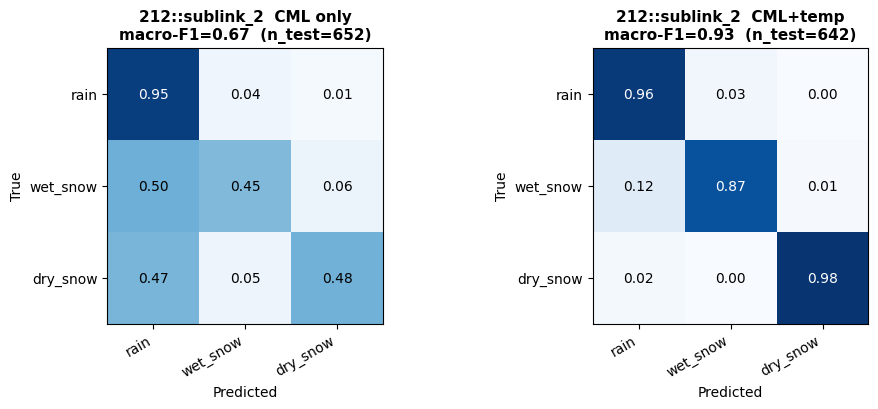

In [4]:
# Confusion matrices for one representative link, CML-only vs +temp
SL = '212::sublink_2'
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, wt in zip(axes, (False, True)):
    X, y, _ = C.single_link_dataset(NC, SL, with_temp=wt, att_var=ATT_VAR)
    C.plot_confusion(C.train_eval(X, y), ax=ax,
                     title=f'{SL}  {"CML+temp" if wt else "CML only"}')
fig.tight_layout(); plt.show()

## 3.3 — Multi-link joint classifier (feature vector across all 5 links)
Features from all 5 links concatenated, aligned on hours where every link reports.
This is the **headline test**: does spatial diversity recover wet-vs-dry snow **without**
temperature?

--- multi-link, temp=False (n_common=829, 45 feats) ---
              precision    recall  f1-score   support

        rain       0.83      0.93      0.88       118
    wet_snow       0.81      0.71      0.76        79
    dry_snow       0.81      0.73      0.77        52

    accuracy                           0.82       249
   macro avg       0.82      0.79      0.80       249
weighted avg       0.82      0.82      0.82       249



--- multi-link, temp=True (n_common=829, 46 feats) ---
              precision    recall  f1-score   support

        rain       0.88      0.96      0.92       118
    wet_snow       0.94      0.81      0.87        79
    dry_snow       0.98      1.00      0.99        52

    accuracy                           0.92       249
   macro avg       0.94      0.92      0.93       249
weighted avg       0.92      0.92      0.92       249



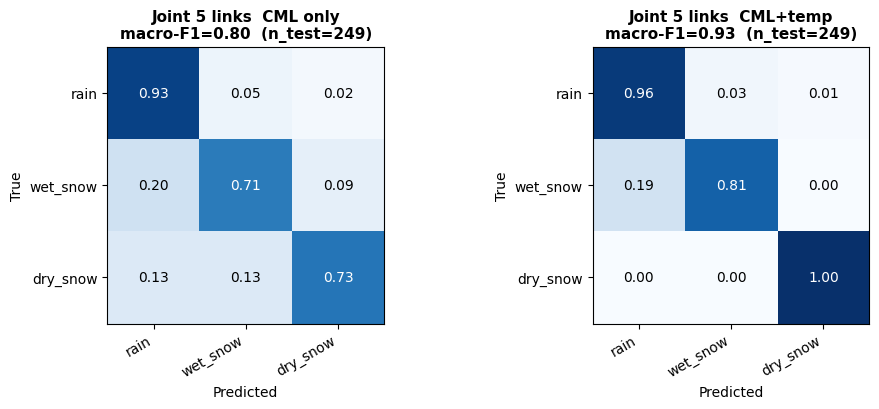

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, wt in zip(axes, (False, True)):
    X, y, cols = C.multi_link_dataset(NC, LINKS, with_temp=wt, att_var=ATT_VAR)
    res = C.train_eval(X, y)
    C.plot_confusion(res, ax=ax, title=f'Joint 5 links  {"CML+temp" if wt else "CML only"}')
    print(f'--- multi-link, temp={wt} (n_common={len(y)}, {len(cols)} feats) ---')
    print(res['report_txt'])
fig.tight_layout(); plt.show()

**Result.** A single V-band link cannot reliably separate wet from dry snow (CML-only
wet/dry F1 ≈ 0.3–0.65). The 5-link joint classifier recovers it at macro-F1 ≈ 0.80 **with
no temperature input** — spatial diversity across paths carries the wet/dry information.
Adding temperature reaches ≈ 0.93 but is partly circular (temperature defines the label).

## 3.5 — Example event: attenuation with predicted phase
A CML-only single-link model applied across a snow-rich week, with the predicted class
shaded under the attenuation trace (rain = blue, wet snow = pink, dry snow = cyan).

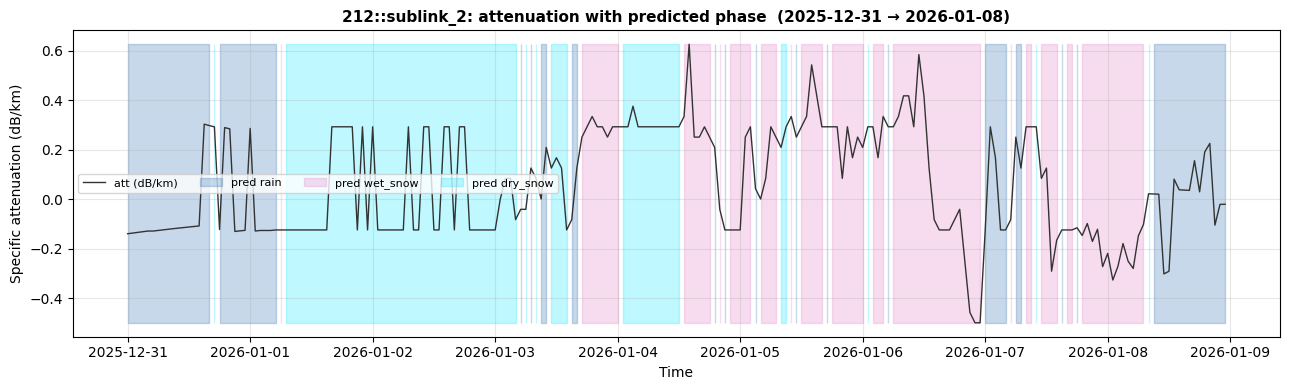

In [6]:
SL = '212::sublink_2'
X, y, cols = C.single_link_dataset(NC, SL, with_temp=False, att_var=ATT_VAR)
model = C.train_eval(X, y)['model']
_ = C.plot_event_example(NC, SL, model, cols, window=EVENT_WINDOW,
                         att_var=ATT_VAR, with_temp=False)
plt.show()